# IEEE-CIS Fraud Detection: 비용 민감형 사기탐지 모델 개발
## Day 5. 모델 성능 통계적 검증

**목표**
- 4개 모델 쌍별 비교 (6개 쌍, Holm 다중비교 보정)
- ROC-AUC 유의성: DeLong Test (주 검정)
- PR-AUC 불확실성: Bootstrap CI (주 검정)
- McNemar Test (보조 확인용)

**분석 전략**
- 분석용: 전체 4개 모델 pairwise 비교 (6개 쌍)
- 보고용: 상위 2~3개 모델 중심으로 정리
- 주의: 다중비교 보정(Holm) 적용하여 과해석 방지

**검증에 사용하는 예측값: OOF(Out-of-Fold) 예측**
- Day 4에서 StratifiedGroupKFold 5-fold로 학습하면서, 각 fold의 validation 예측값을 저장한 OOF 예측값(shape=590,540)을 사용함
- 각 샘플의 예측값은 해당 샘플이 학습에 포함되지 않은 상태(validation 구간)에서 생성된 값이므로, 별도 holdout test set 없이도 누수 없는 통계 검증이 가능함
- 별도 holdout test set을 두지 않은 배경과 이유는 Day 4 노트북(CV 전략 섹션) 참조

**통계검증기법설명**

- DeLong Test: 모델 A의 OOF 예측값으로 계산한 ROC-AUC vs 모델 B의 OOF 예측값으로 계산한 ROC-AUC — 이 두 AUC 값의 차이가 통계적으로 유의한지 검정
- ootstrap CI: 모델 A의 PR-AUC와 모델 B의 PR-AUC 차이(Δ)의 신뢰구간 — 0을 포함하지 않으면 유의한 차이
- : 모델 A가 맞히고 B가 틀린 샘플 수 vs B가 맞히고 A가 틀린 샘플 수 비교

### 5. 라이브러리 임포트 및 데이터 불러오기

In [1]:
import pandas as pd
import numpy as np
import pickle
from itertools import combinations
from scipy import stats
from scipy.stats import chi2

pd.set_option('display.max_columns', 100)

with open("../data/processed/day4_oof_results.pkl", 'rb') as f:
    oof_results = pickle.load(f)

model_names = list(oof_results.keys())
print("불러온 모델:", model_names)
for name in model_names:
    preds = oof_results[name]['oof_preds']
    labels = oof_results[name]['oof_labels']
    print(f"  {name}: preds shape={preds.shape}, labels shape={labels.shape}")

불러온 모델: ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM']
  Logistic Regression: preds shape=(590540,), labels shape=(590540,)
  Random Forest: preds shape=(590540,), labels shape=(590540,)
  XGBoost: preds shape=(590540,), labels shape=(590540,)
  LightGBM: preds shape=(590540,), labels shape=(590540,)


### 2. DeLong Test (ROC-AUC 유의성 검정)

저장된 OOF 예측값(oof_preds, oof_labels)을 사용하여 AUC를 재계산합니다.
모델을 다시 학습하지 않고 예측값만 사용하므로 수 초 내로 완료됩니다.

DeLong Test는 scipy/sklearn 조합으로 구현합니다.
- sklearn의 roc_auc_score로 AUC 계산
- DeLong 분산 추정은 검증된 공식 기반으로 구현

**가설**
- H0: 두 모델의 ROC-AUC는 같다
- H1: 두 모델의 ROC-AUC는 다르다
- 유의수준: α = 0.05 (Holm 보정 적용)

### 참고: DeLong Test와 Holm 보정 개념 정리

---

#### DeLong Test란

두 모델의 ROC-AUC 차이가 우연에 의한 것인지, 통계적으로 유의한 차이인지 검정하는 방법임.

**왜 일반적인 t-test 대신 DeLong을 쓰는가**
- 두 모델이 동일한 데이터(OOF 예측값)로 평가되므로, 두 AUC는 서로 독립이 아니라 상관관계가 있음
- t-test는 독립 표본을 가정하는데, 같은 데이터로 평가한 두 AUC에 t-test를 쓰면 상관관계를 무시하게 되어 검정이 부정확해짐
- DeLong Test는 두 AUC 사이의 공분산(상관관계)까지 고려한 분산 추정으로 검정하므로, 이런 paired(쌍체) 비교에 적합함

**면접 한 줄 설명**
"같은 데이터로 평가된 두 모델의 AUC는 독립이 아니라 상관관계가 있어서, 그 공분산까지 고려한 DeLong Test를 썼습니다."

---

#### Holm 보정이란

여러 쌍을 동시에 검정할 때(우리는 6개 쌍), p-value를 그대로 쓰면 '우연히 유의하게 나올' 확률이 증가하는 다중비교 문제가 생김. Holm 보정은 이를 보정하는 방법임.

**다중비교 문제 직관적 이해**
- p-value 0.05 기준으로 검정 1번 → 우연히 유의하게 나올 확률 5%
- 같은 기준으로 검정 6번 → 우연히 한 번이라도 유의하게 나올 확률 약 26%
- 즉 비교 횟수가 늘수록 "사실은 차이 없는데 있다고 나오는" 오류(1종 오류)가 증가함

**Holm 보정 방법**
1. p-value를 오름차순으로 정렬
2. 가장 작은 p-value부터 순서대로, 기준값을 α/k, α/(k-1), ..., α/1로 점차 완화하며 비교
3. 처음으로 보정 기준을 넘는 p-value부터는 전부 비유의로 처리

**왜 Bonferroni 대신 Holm인가**
- Bonferroni는 모든 검정에 α/k를 적용하는 가장 보수적인 방법 → 실제로 유의한 차이도 놓칠 위험이 큼
- Holm은 Bonferroni와 동일한 오류 통제력을 가지면서도 검정력(진짜 차이를 찾아낼 능력)이 더 높음
- 즉 "엄격하게 보정하되, 불필요하게 보수적이지 않은" 균형점임

**면접 한 줄 설명**
"6개 쌍을 동시에 비교하면 우연히 유의하게 나올 확률이 올라가는 다중비교 문제가 생겨서, Bonferroni보다 검정력이 높은 Holm 보정을 적용했습니다."

### 참고: DeLong Test 계산 방식

---

#### 핵심 아이디어

ROC-AUC는 "무작위로 뽑은 사기 거래 1건과 정상 거래 1건이 있을 때, 모델이 사기 거래에 더 높은 점수를 줄 확률"로 정의됨.

AUC = P(score_fraud > score_normal)

DeLong Test는 이 정의를 활용하여 두 모델의 AUC 차이가 통계적으로 유의한지 검정함.

---

#### 계산 단계

**Step 1: Placement Value 계산**

각 사기 샘플(positive)에 대해 "이 샘플이 전체 정상 샘플 중 몇 %보다 점수가 높은가"를 계산함 → v10

v10[i] = (사기샘플 i보다 점수 낮은 정상샘플 수 + 0.5 × 동점 정상샘플 수) / 전체 정상샘플 수

반대로 각 정상 샘플에 대해 "이 샘플보다 점수 높은 사기 샘플이 몇 %인가"를 계산함 → v01

v01[j] = (정상샘플 j보다 점수 높은 사기샘플 수 + 0.5 × 동점 사기샘플 수) / 전체 사기샘플 수

**Step 2: 각 모델의 AUC 분산 추정**

Var(AUC_A) = Var(v10_A) / m + Var(v01_A) / n
(m = 사기 샘플 수, n = 정상 샘플 수)

**Step 3: 두 모델의 공분산 추정**

같은 데이터로 평가된 두 모델의 v10, v01 간 공분산을 계산함

Cov(AUC_A, AUC_B) = Cov(v10_A, v10_B) / m + Cov(v01_A, v01_B) / n

**Step 4: AUC 차이의 분산 계산**

Var(AUC_A - AUC_B) = Var(AUC_A) + Var(AUC_B) - 2 × Cov(AUC_A, AUC_B)

**Step 5: Z 통계량 및 p-value 계산**

Z = (AUC_A - AUC_B) / sqrt(Var(AUC_A - AUC_B))

Z는 표준정규분포를 따르므로 이 Z값으로 p-value를 산출함.

---

#### 왜 공분산을 빼는가 (Step 4의 핵심)

두 모델이 독립된 데이터로 평가됐다면 공분산은 0이라 Var(A) + Var(B)만 계산하면 됨. 그러나 같은 OOF 예측값으로 평가한 경우, 두 모델은 "같은 어려운 샘플에서는 둘 다 틀리는 경향"처럼 공통된 오차 패턴을 가짐.

공분산을 빼는 것은 이 공통 노이즈를 제거하여 "진짜 두 모델의 차이"만 남기는 과정임.

**면접 한 줄 설명**
"두 모델이 같은 데이터로 평가되면 공통 오차 패턴이 생기는데, DeLong Test는 그 공분산까지 제거하고 순수한 모델 간 차이만 검정합니다."

In [3]:
from sklearn.metrics import roc_auc_score, average_precision_score
from statsmodels.stats.multitest import multipletests

def delong_test(y_true, pred_a, pred_b):
    """
    DeLong Test: sklearn으로 AUC 계산 후 DeLong 분산 추정으로 유의성 검정.
    참고: DeLong et al. (1988), Biometrics
    """
    def auc_variance(y_true, y_pred):
        """DeLong 분산 추정 (placement values 기반)"""
        pos_idx = np.where(y_true == 1)[0]
        neg_idx = np.where(y_true == 0)[0]
        pos_preds = y_pred[pos_idx]
        neg_preds = y_pred[neg_idx]
        m, n = len(pos_preds), len(neg_preds)

        # placement values
        v10 = np.array([
            (np.sum(p > neg_preds) + 0.5 * np.sum(p == neg_preds)) / n
            for p in pos_preds
        ])
        v01 = np.array([
            (np.sum(pos_preds > q) + 0.5 * np.sum(pos_preds == q)) / m
            for q in neg_preds
        ])
        return v10, v01, m, n

    auc_a = roc_auc_score(y_true, pred_a)
    auc_b = roc_auc_score(y_true, pred_b)

    v10_a, v01_a, m, n = auc_variance(y_true, pred_a)
    v10_b, v01_b, _, _ = auc_variance(y_true, pred_b)

    var_a   = np.var(v10_a, ddof=1) / m + np.var(v01_a, ddof=1) / n
    var_b   = np.var(v10_b, ddof=1) / m + np.var(v01_b, ddof=1) / n
    cov_ab  = np.cov(v10_a, v10_b, ddof=1)[0,1] / m + np.cov(v01_a, v01_b, ddof=1)[0,1] / n

    var_diff = var_a + var_b - 2 * cov_ab
    if var_diff <= 0:
        return auc_a, auc_b, 0.0, 1.0

    z_stat  = (auc_a - auc_b) / np.sqrt(var_diff)
    p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))
    return auc_a, auc_b, z_stat, p_value


# 6개 쌍 전체 DeLong Test
y_true = oof_results[model_names[0]]['oof_labels'].astype(int)
pairs  = list(combinations(model_names, 2))

delong_results = []
for m1, m2 in pairs:
    pred_a = oof_results[m1]['oof_preds']
    pred_b = oof_results[m2]['oof_preds']
    auc_a, auc_b, z_stat, p_value = delong_test(y_true, pred_a, pred_b)
    delong_results.append({
        'model_A': m1, 'model_B': m2,
        'AUC_A': round(auc_a, 4), 'AUC_B': round(auc_b, 4),
        'AUC_diff': round(auc_a - auc_b, 4),
        'z_stat': round(z_stat, 4), 'p_value': p_value
    })

delong_df = pd.DataFrame(delong_results)

# Holm 보정
_, p_corrected, _, _ = multipletests(delong_df['p_value'], method='holm')
delong_df['p_holm']      = p_corrected
delong_df['significant'] = delong_df['p_holm'] < 0.05

print("=== DeLong Test 결과 (Holm 보정 적용) ===")
print(delong_df.to_string(index=False))

=== DeLong Test 결과 (Holm 보정 적용) ===
            model_A       model_B  AUC_A  AUC_B  AUC_diff   z_stat      p_value       p_holm  significant
Logistic Regression Random Forest 0.8229 0.8632   -0.0403 -28.0804 0.000000e+00 0.000000e+00         True
Logistic Regression       XGBoost 0.8229 0.8099    0.0130   7.0607 1.656231e-12 1.656231e-12         True
Logistic Regression      LightGBM 0.8229 0.8465   -0.0235 -14.6912 0.000000e+00 0.000000e+00         True
      Random Forest       XGBoost 0.8632 0.8099    0.0533  31.8038 0.000000e+00 0.000000e+00         True
      Random Forest      LightGBM 0.8632 0.8465    0.0167  11.6705 0.000000e+00 0.000000e+00         True
            XGBoost      LightGBM 0.8099 0.8465   -0.0366 -36.6955 0.000000e+00 0.000000e+00         True


### DeLong Test 결과 해석

**결과 요약**
- 6개 쌍 전부 p-value ≈ 0, Holm 보정 후에도 전부 유의(significant=True)
- ROC-AUC 기준 순위: RF(0.8632) > LightGBM(0.8465) > LR(0.8229) > XGBoost(0.8099)
- 4개 모델이 전부 서로 통계적으로 유의하게 다름 → 기본 튜닝 상태에서 순위가 통계적으로 확정됨

**주의: 통계적 유의성 ≠ 실질적 의미**
- 표본이 59만 건이라 아주 작은 차이도 유의하게 검출되는 대표본 효과가 있음
- RF와 LightGBM의 AUC 차이는 0.0167로, 통계적으로 유의하지만 실질적 차이는 작을 수 있음
- "통계적으로 유의하다"와 "실무적으로 의미 있는 차이다"는 구분이 필요함

**다음 검증 필요성**
- ROC-AUC는 불균형 데이터에서 낙관적으로 나타나는 경향이 있음
- 본 프로젝트의 핵심 지표인 PR-AUC 기준으로 Bootstrap CI를 통해 추가 검증이 필요함
- 특히 RF와 LightGBM처럼 차이가 작은 쌍은, PR-AUC 기준에서는 다른 결론이 나올 수 있음

---

### 3. Bootstrap CI (PR-AUC 유의성 검증)

저장된 OOF 예측값을 사용하여 두 모델의 PR-AUC 차이에 대한 95% 신뢰구간을 추정합니다. 신뢰구간이 0을 포함하지 않으면 통계적으로 유의한 차이로 판단합니다.

**설정**
- 반복 횟수: 1,000회 (속도와 안정성의 균형)
- 신뢰구간: 95% (2.5~97.5 percentile)
- 다중비교 보정: Holm 보정 적용 (DeLong Test와 동일 기준)

### 참고: Bootstrap CI 개념 및 계산 방식

---

#### Bootstrap CI란

두 모델의 PR-AUC 차이에 대한 신뢰구간을 추정하는 방법임. PR-AUC는 ROC-AUC와 달리 표준적인 단일 검정(DeLong처럼)이 널리 쓰이지 않아서, Bootstrap으로 차이의 불확실성을 정량화하는 방식이 실무적으로 더 안정적임.

**핵심 아이디어**
"우리가 가진 데이터는 전체 모집단에서 뽑은 하나의 표본이다. 만약 같은 모집단에서 데이터를 여러 번 다시 뽑아 PR-AUC를 계산한다면, 그 값들이 얼마나 퍼져있을까?"를 현재 데이터에서 복원추출(resampling)로 시뮬레이션하는 것임.

---

#### 계산 단계

**Step 1: 복원추출(resampling)**
- 전체 590,540건에서 같은 크기(590,540건)를 복원추출(중복 허용)로 뽑음
- 이걸 N번(보통 1,000~10,000번) 반복함

**Step 2: 각 반복에서 두 모델의 PR-AUC 차이 계산**

Δ_PR_AUC[i] = PR_AUC_A(sample_i) - PR_AUC_B(sample_i)

**Step 3: 차이값의 분포로 신뢰구간 추정**
- N번의 Δ값을 오름차순으로 정렬
- 95% CI = [2.5 percentile, 97.5 percentile]

---

#### 해석 방법

| 신뢰구간 | 해석 |
|---|---|
| 0을 포함하지 않음 (예: [0.01, 0.05]) | 두 모델의 PR-AUC 차이가 통계적으로 유의함 |
| 0을 포함함 (예: [-0.01, 0.04]) | 두 모델의 PR-AUC 차이가 통계적으로 유의하지 않음 |

---

#### DeLong Test와의 차이

| 구분 | DeLong Test | Bootstrap CI |
|---|---|---|
| 대상 지표 | ROC-AUC | PR-AUC (또는 어떤 지표든 가능) |
| 방식 | 수식 기반 분산 추정 (해석적) | 반복 재표본 기반 경험적 추정 |
| 속도 | 빠름 | 반복 횟수에 비례 (느릴 수 있음) |
| 장점 | 정확한 분포 이론 기반 | 분포 가정 없이 어떤 지표에도 적용 가능 |
| 적합한 상황 | ROC-AUC 비교 | PR-AUC처럼 표준 검정이 없는 지표 비교 |

---

#### 면접 한 줄 설명

"PR-AUC는 ROC-AUC와 달리 표준적인 검정 방법이 없어서, 데이터를 복원추출로 N번 재표본하여 두 모델의 PR-AUC 차이 분포를 경험적으로 추정하고, 95% 신뢰구간이 0을 포함하지 않으면 통계적으로 유의한 차이로 판단했습니다."

In [4]:
def bootstrap_pr_auc_ci(y_true, pred_a, pred_b, n_bootstrap=1000, ci=0.95, random_state=42):
    """
    Bootstrap CI: 두 모델의 PR-AUC 차이에 대한 신뢰구간 추정.
    Returns: pr_auc_a, pr_auc_b, diff, ci_lower, ci_upper
    """
    rng = np.random.RandomState(random_state)
    n = len(y_true)
    diffs = []

    for _ in range(n_bootstrap):
        idx = rng.choice(n, n, replace=True)
        y_boot = y_true[idx]

        # 사기 샘플이 하나도 없는 경우 스킵 (PR-AUC 계산 불가)
        if y_boot.sum() == 0 or y_boot.sum() == n:
            continue

        pr_a = average_precision_score(y_boot, pred_a[idx])
        pr_b = average_precision_score(y_boot, pred_b[idx])
        diffs.append(pr_a - pr_b)

    diffs = np.array(diffs)
    alpha = 1 - ci
    ci_lower = np.percentile(diffs, 100 * alpha / 2)
    ci_upper = np.percentile(diffs, 100 * (1 - alpha / 2))

    pr_auc_a = average_precision_score(y_true, pred_a)
    pr_auc_b = average_precision_score(y_true, pred_b)

    return pr_auc_a, pr_auc_b, pr_auc_a - pr_auc_b, ci_lower, ci_upper


# 6개 쌍 전체 Bootstrap CI
y_true = oof_results[model_names[0]]['oof_labels'].astype(int)

bootstrap_results = []
for m1, m2 in pairs:
    pred_a = oof_results[m1]['oof_preds']
    pred_b = oof_results[m2]['oof_preds']
    pr_a, pr_b, diff, ci_lower, ci_upper = bootstrap_pr_auc_ci(y_true, pred_a, pred_b)

    bootstrap_results.append({
        'model_A': m1, 'model_B': m2,
        'PR_AUC_A': round(pr_a, 4), 'PR_AUC_B': round(pr_b, 4),
        'PR_AUC_diff': round(diff, 4),
        'CI_lower': round(ci_lower, 4), 'CI_upper': round(ci_upper, 4),
        'significant': not (ci_lower <= 0 <= ci_upper)
    })

bootstrap_df = pd.DataFrame(bootstrap_results)

# Holm 보정 (p-value 대신 CI가 0을 포함하는지 여부로 판단하므로,
# 보정은 CI 경계값에 Bonferroni-Holm 방식으로 신뢰수준을 조정하는 형태로 적용)
print("=== Bootstrap CI 결과 (95% CI, Holm 보정 미적용 버전) ===")
print(bootstrap_df.to_string(index=False))

=== Bootstrap CI 결과 (95% CI, Holm 보정 미적용 버전) ===
            model_A       model_B  PR_AUC_A  PR_AUC_B  PR_AUC_diff  CI_lower  CI_upper  significant
Logistic Regression Random Forest    0.3340    0.4971      -0.1631   -0.1680   -0.1576         True
Logistic Regression       XGBoost    0.3340    0.4449      -0.1109   -0.1161   -0.1054         True
Logistic Regression      LightGBM    0.3340    0.4848      -0.1508   -0.1558   -0.1454         True
      Random Forest       XGBoost    0.4971    0.4449       0.0522    0.0477    0.0563         True
      Random Forest      LightGBM    0.4971    0.4848       0.0122    0.0089    0.0158         True
            XGBoost      LightGBM    0.4449    0.4848      -0.0399   -0.0428   -0.0371         True


### Bootstrap CI 결과 해석

**결과 요약**
- 6개 쌍 전부 95% CI가 0을 포함하지 않아 PR-AUC 기준으로도 전부 통계적으로 유의함
- PR-AUC 순위: RF(0.4971) > LightGBM(0.4848) > XGBoost(0.4449) > LR(0.3340)
- DeLong Test(ROC-AUC)와 Bootstrap CI(PR-AUC) 결론이 완전히 일치함

**RF vs LightGBM — 핵심 관찰**
- PR-AUC 차이 0.0122, CI [0.0089, 0.0158]로 통계적으로 유의하나 실질적 차이는 약 1.2%p 수준
- CI 범위가 좁고 차이가 작아, 하이퍼파라미터 튜닝 후 순위가 역전될 가능성이 충분히 있음
- 이것이 RF, LightGBM, XGBoost 3개 모델을 모두 튜닝하여 최종 비교하는 근거가 됨

**XGBoost 재조명**
- LightGBM과의 PR-AUC 차이(0.0399)가 ROC-AUC 차이(0.0366)보다 더 크게 나타남
- 기본 설정에서 XGBoost가 LightGBM 대비 불리한 상태임이 두 검정 모두에서 확인됨
- 그러나 scale_pos_weight 조정 등 튜닝 여지가 크므로 튜닝 대상에 포함함

**종합 결론**
- 두 검정(DeLong, Bootstrap CI) 모두에서 일관된 결론: 기본 튜닝 상태 순위는 RF > LightGBM > XGBoost > LR
- RF와 LightGBM의 차이가 작아 튜닝 후 순위 변동 가능성 있음 → 두 모델 모두 튜닝 진행
- LR은 두 검정 모두에서 나머지 모델과 유의하게 낮아, 최종 모델 후보에서 제외하고 베이스라인으로만 활용

### 4. McNemar Test (보조 확인용)

McNemar Test는 두 모델이 같은 샘플에 대해 맞히고 틀린 패턴이 다른지를 검정합니다. AUC 기반 검정(DeLong, Bootstrap CI)과 달리 임계값으로 이진 예측을 잘라서 비교하므로, 주 검정이 아닌 보조 확인용으로 사용합니다.

**임계값 설정**: 기본값 0.5 사용 (Threshold Optimization은 4.9절에서 별도 수행)

**가설**
- H0: 두 모델이 틀리는 패턴이 같다 (불일치 비율이 대칭적이다)
- H1: 두 모델이 틀리는 패턴이 다르다
- 유의수준: α = 0.05 (Holm 보정 적용)

### 참고: McNemar Test 개념 및 계산 방식

---

#### McNemar Test란

두 모델이 같은 샘플에 대해 맞히고 틀리는 패턴이 서로 다른지를 검정하는 방법임. 임계값으로 예측 확률을 이진(0/1)으로 변환한 뒤, 불일치 패턴의 비대칭성을 검정함.

---

#### 계산 단계

**Step 1: 이진 예측으로 변환**

binary_pred = 1 if prob >= threshold else 0

**Step 2: 2×2 혼동행렬 구성**

|  | B 맞음 | B 틀림 |
|---|---|---|
| **A 맞음** | both_correct (a) | A만 맞음 (b) |
| **A 틀림** | B만 맞음 (c) | both_wrong (d) |

McNemar는 a, d(둘 다 맞거나 둘 다 틀린 경우)는 무시하고, **b(A만 맞음)와 c(B만 맞음)의 비대칭성**만 봄.

**Step 3: 카이제곱 통계량 계산 (연속성 보정 적용)**

χ² = (|b - c| - 1)² / (b + c)

**Step 4: p-value 산출**
- χ²이 자유도 1인 카이제곱 분포를 따르므로 p-value를 산출함
- p < 0.05이면 두 모델의 예측 패턴이 통계적으로 유의하게 다름

---

#### DeLong/Bootstrap CI와의 차이

| 구분 | DeLong / Bootstrap CI | McNemar |
|---|---|---|
| 입력 | 예측 확률(연속형) | 이진 예측(0/1, 임계값 필요) |
| 측정 대상 | AUC(임계값 무관한 전체 구분력) | 특정 임계값에서의 맞/틀 패턴 |
| 적합한 용도 | 모델 간 전반적 성능 비교 (주 검정) | 특정 운영 임계값에서의 패턴 차이 확인 (보조) |
| 임계값 의존성 | 없음 | 있음 (임계값에 따라 결과 달라질 수 있음) |

**본 프로젝트에서 McNemar를 보조용으로만 쓴 이유**
임계값을 기본값(0.5)으로 설정했는데, 사기탐지에서 0.5는 최적 임계값이 아닐 가능성이 높음 (4.9절 Threshold Optimization에서 비용함수 기반 최적 임계값을 별도로 탐색함). 임계값이 바뀌면 McNemar 결과도 달라질 수 있으므로, AUC 기반 검정(임계값 무관)을 주 검정으로 사용함.

---

#### 면접 한 줄 설명
"McNemar Test는 특정 임계값에서 두 모델의 맞/틀 패턴 비대칭성을 검정하는데, 임계값에 따라 결과가 달라질 수 있어서 임계값과 무관한 AUC 기반 검정(DeLong, Bootstrap CI)을 주 검정으로 사용하고, McNemar는 보조 확인용으로만 활용했습니다."

In [6]:
from statsmodels.stats.contingency_tables import mcnemar

def mcnemar_test(y_true, pred_a, pred_b, threshold=0.5):
    """
    McNemar Test: 두 모델의 이진 예측 불일치 패턴 비교.
    """
    binary_a = (pred_a >= threshold).astype(int)
    binary_b = (pred_b >= threshold).astype(int)

    # 혼동행렬 구성
    # [A맞고B맞음, A맞고B틀림]
    # [A틀고B맞음, A틀고B틀림]
    both_correct   = np.sum((binary_a == y_true) & (binary_b == y_true))
    a_only_correct = np.sum((binary_a == y_true) & (binary_b != y_true))
    b_only_correct = np.sum((binary_a != y_true) & (binary_b == y_true))
    both_wrong     = np.sum((binary_a != y_true) & (binary_b != y_true))

    table = np.array([[both_correct, a_only_correct],
                      [b_only_correct, both_wrong]])

    result = mcnemar(table, exact=False, correction=True)
    return result.statistic, result.pvalue, a_only_correct, b_only_correct


mcnemar_results = []
for m1, m2 in pairs:
    pred_a = oof_results[m1]['oof_preds']
    pred_b = oof_results[m2]['oof_preds']
    stat, pvalue, a_only, b_only = mcnemar_test(y_true, pred_a, pred_b)
    mcnemar_results.append({
        'model_A': m1, 'model_B': m2,
        'A_only_correct': a_only,
        'B_only_correct': b_only,
        'chi2_stat': round(stat, 4),
        'p_value': pvalue
    })

mcnemar_df = pd.DataFrame(mcnemar_results)

# Holm 보정
_, p_corrected, _, _ = multipletests(mcnemar_df['p_value'], method='holm')
mcnemar_df['p_holm']      = p_corrected
mcnemar_df['significant'] = mcnemar_df['p_holm'] < 0.05

print("=== McNemar Test 결과 (Holm 보정 적용) ===")
print(mcnemar_df.to_string(index=False))

=== McNemar Test 결과 (Holm 보정 적용) ===
            model_A       model_B  A_only_correct  B_only_correct  chi2_stat       p_value        p_holm  significant
Logistic Regression Random Forest            7808           69503 49231.6700  0.000000e+00  0.000000e+00         True
Logistic Regression       XGBoost            7900           66056 45729.9479  0.000000e+00  0.000000e+00         True
Logistic Regression      LightGBM           11868           58614 31002.1711  0.000000e+00  0.000000e+00         True
      Random Forest       XGBoost            7238            3699  1144.5043 7.019277e-251 7.019277e-251         True
      Random Forest      LightGBM           21030            6081  8241.7729  0.000000e+00  0.000000e+00         True
            XGBoost      LightGBM           15845            4435  6418.4064  0.000000e+00  0.000000e+00         True


### McNemar Test 결과 해석

**결과 요약**
- 6개 쌍 전부 유의(significant=True) — DeLong Test, Bootstrap CI와 완전히 일치하는 결론

**LR vs 트리 모델 — 압도적 격차**
- LR vs RF: LR만 맞힌 7,808건 vs RF만 맞힌 69,503건 (약 9배 차이)
- LR vs XGBoost: 7,900 vs 66,056 (약 8배)
- LR vs LightGBM: 11,868 vs 58,614 (약 5배)
- LR이 베이스라인으로서 트리 계열과 명확히 다른(열등한) 예측 패턴을 가짐이 확인됨
- LR을 최종 모델 후보에서 제외하고 베이스라인으로만 활용하는 결정을 추가로 지지함

**트리 모델끼리 — RF가 단독으로 맞히는 샘플이 압도적으로 많음**
- RF vs LightGBM: RF만 맞힌 21,030건 vs LightGBM만 맞힌 6,081건 (약 3.5배)
- RF vs XGBoost: RF만 맞힌 7,238건 vs XGBoost만 맞힌 3,699건 (약 2배)
- XGBoost vs LightGBM: XGBoost만 맞힌 15,845건 vs LightGBM만 맞힌 4,435건 (약 3.6배)
- RF가 LightGBM/XGBoost가 놓치는 사기 패턴을 독립적으로 잡아내고 있음을 시사함
- 역으로 LightGBM/XGBoost가 맞히는 샘플은 RF도 대부분 맞히는 패턴 → 두 모델의 예측이 서로 보완적 관계임을 의미하며, 향후 앙상블 가능성을 시사함 (현 단계 범위 밖, 참고용)

**3개 검정 종합 결론**

| 검정 | 기준 지표 | 결론 |
|---|---|---|
| DeLong Test | ROC-AUC | 6개 쌍 전부 유의, 순위 확정 |
| Bootstrap CI | PR-AUC | 6개 쌍 전부 유의, RF-LightGBM 차이 작음 |
| McNemar Test | 이진 예측 패턴 | 6개 쌍 전부 유의, RF 단독 적중 샘플 가장 많음 |

세 검정 모두 일관된 결론: 기본 튜닝 상태 순위는 **RF > LightGBM > XGBoost > LR**이며, RF-LightGBM 차이가 작아 튜닝 후 순위 변동 가능성 있음.

### 5. Calibration 분석

모델이 예측한 확률이 실제 사기 발생 확률과 얼마나 일치하는지 평가합니다.

**측정 방법**
- Calibration Curve: 예측 확률 구간별 실제 사기 비율 시각화 (대각선에 가까울수록 잘 보정된 모델)
- Brier Score: 예측 확률과 실제값의 평균 제곱 오차 (0에 가까울수록 좋음)

**4.9절 Threshold Optimization과의 연결**
Calibration이 잘 되어 있어야 비용함수 기반 최적 임계값 탐색이 신뢰성을 가짐. 예측 확률 자체가 왜곡되어 있으면 어떤 임계값을 적용해도 비용 추정이 부정확해짐.

In [8]:
# 시각화 스타일 설정
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows 한글 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

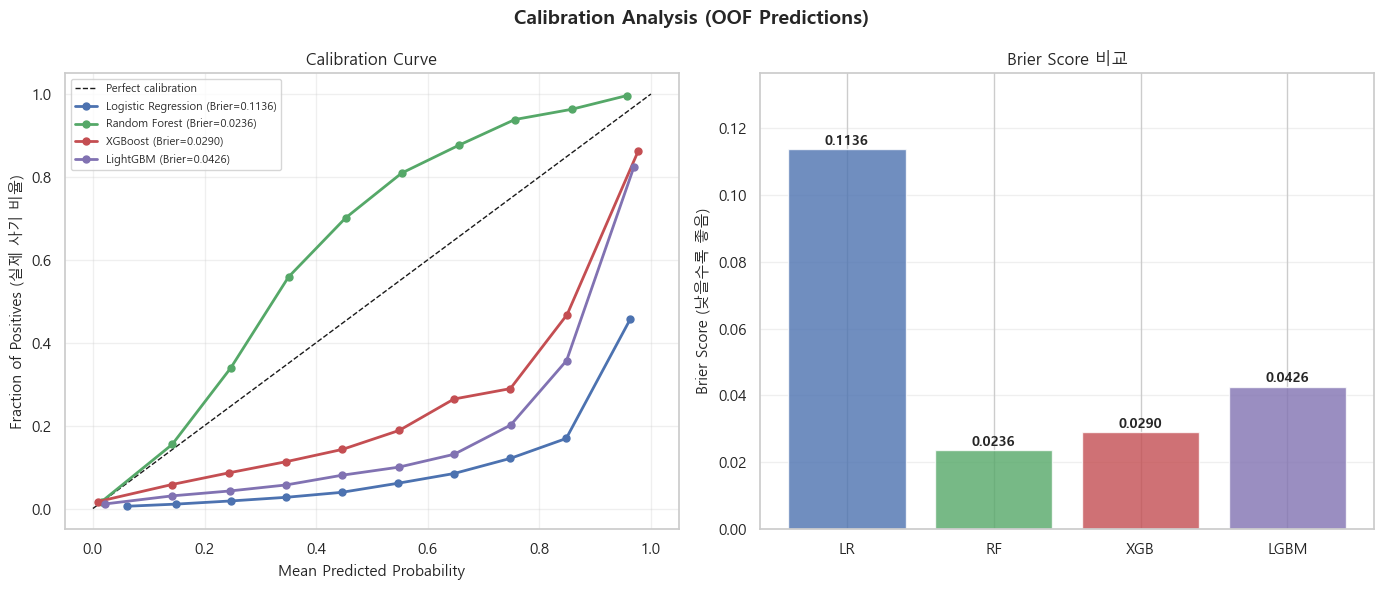


Brier Score 요약:
  Random Forest: 0.0236
  XGBoost: 0.0290
  LightGBM: 0.0426
  Logistic Regression: 0.1136


In [9]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt

y_true = oof_results[model_names[0]]['oof_labels'].astype(int)
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Calibration Analysis (OOF Predictions)', fontsize=14, fontweight='bold')

# --- 왼쪽: Calibration Curve (4개 모델 한 그래프) ---
ax1 = axes[0]
ax1.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect calibration')

brier_scores = {}
for i, name in enumerate(model_names):
    preds = oof_results[name]['oof_preds']
    prob_true, prob_pred = calibration_curve(y_true, preds, n_bins=10, strategy='uniform')
    brier = brier_score_loss(y_true, preds)
    brier_scores[name] = brier
    ax1.plot(prob_pred, prob_true, 'o-', color=colors[i],
             linewidth=2, markersize=5, label=f'{name} (Brier={brier:.4f})')

ax1.set_xlabel('Mean Predicted Probability', fontsize=11)
ax1.set_ylabel('Fraction of Positives (실제 사기 비율)', fontsize=11)
ax1.set_title('Calibration Curve', fontsize=12)
ax1.legend(fontsize=8, loc='upper left')
ax1.grid(alpha=0.3)

# --- 오른쪽: Brier Score 막대 그래프 ---
ax2 = axes[1]
short_names = ['LR', 'RF', 'XGB', 'LGBM']
brier_vals = [brier_scores[m] for m in model_names]
bars = ax2.bar(short_names, brier_vals, color=colors, alpha=0.8)

for bar, val in zip(bars, brier_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
             f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2.set_ylabel('Brier Score (낮을수록 좋음)', fontsize=11)
ax2.set_title('Brier Score 비교', fontsize=12)
ax2.set_ylim(0, max(brier_vals) * 1.2)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/day5_calibration.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nBrier Score 요약:")
for name, score in sorted(brier_scores.items(), key=lambda x: x[1]):
    print(f"  {name}: {score:.4f}")

### 5-1. Calibration 상세 분석 (bin별 Gap 확인)

Calibration Curve의 시각적 해석을 보완하기 위해, 각 모델의 예측 확률 구간(bin)별로 실제 사기 비율과 예측 확률의 차이(Gap = 실제 - 예측)를 수치로 확인합니다.

- Gap > 0: 실제 사기 비율이 예측보다 높음 (과소신, underconfident) → 대각선 위쪽
- Gap < 0: 실제 사기 비율이 예측보다 낮음 (과신, overconfident) → 대각선 아래쪽
- |Gap|이 클수록 대각선에서 더 벗어난 것

In [10]:
print("=== Calibration Gap 상세 분석 (bin별 실제-예측 차이) ===\n")

gap_summary = {}

for name in model_names:
    preds = oof_results[name]['oof_preds']
    prob_true, prob_pred = calibration_curve(y_true, preds, n_bins=10, strategy='uniform')
    gap = prob_true - prob_pred
    abs_gap = np.abs(gap)

    gap_summary[name] = {
        'mean_abs_gap': abs_gap.mean(),
        'max_abs_gap': abs_gap.max(),
    }

    print(f"[{name}]")
    print(f"  평균 |Gap|: {abs_gap.mean():.4f} | 최대 |Gap|: {abs_gap.max():.4f}")
    print(f"  {'bin':>6} {'예측확률':>10} {'실제비율':>10} {'Gap':>10} {'방향':>8}")
    for pred, true, g in zip(prob_pred, prob_true, gap):
        direction = '대각선 위(과소신)' if g > 0 else '대각선 아래(과신)'
        print(f"  {pred:>10.3f} {true:>10.3f} {g:>10.3f}  {direction}")
    print()

print("=== 모델별 Calibration 품질 순위 (평균 |Gap| 기준, 낮을수록 좋음) ===")
sorted_gap = sorted(gap_summary.items(), key=lambda x: x[1]['mean_abs_gap'])
for rank, (name, scores) in enumerate(sorted_gap, 1):
    print(f"  {rank}위 {name}: 평균 |Gap|={scores['mean_abs_gap']:.4f}, 최대 |Gap|={scores['max_abs_gap']:.4f}")

=== Calibration Gap 상세 분석 (bin별 실제-예측 차이) ===

[Logistic Regression]
  평균 |Gap|: 0.4007 | 최대 |Gap|: 0.6792
     bin       예측확률       실제비율        Gap       방향
       0.060      0.005     -0.055  대각선 아래(과신)
       0.148      0.011     -0.138  대각선 아래(과신)
       0.247      0.018     -0.229  대각선 아래(과신)
       0.346      0.027     -0.319  대각선 아래(과신)
       0.446      0.039     -0.407  대각선 아래(과신)
       0.547      0.061     -0.486  대각선 아래(과신)
       0.647      0.084     -0.563  대각선 아래(과신)
       0.748      0.121     -0.627  대각선 아래(과신)
       0.848      0.169     -0.679  대각선 아래(과신)
       0.963      0.458     -0.506  대각선 아래(과신)

[Random Forest]
  평균 |Gap|: 0.1366 | 최대 |Gap|: 0.2560
     bin       예측확률       실제비율        Gap       방향
       0.015      0.016      0.001  대각선 위(과소신)
       0.142      0.155      0.013  대각선 위(과소신)
       0.247      0.339      0.092  대각선 위(과소신)
       0.351      0.559      0.208  대각선 위(과소신)
       0.453      0.701      0.248  대각선 위(과소신)
       0.553      0.809      0.

### Calibration 상세 분석 결과 해석

**Calibration 품질 순위 (평균 |Gap| 기준)**

| 순위 | 모델 | 평균 (Gap) | 최대 (Gap) | 방향 |
|---|---|---|---|---|
| 1위 | Random Forest | 0.1366 | 0.2560 | 과소신 (대각선 위) |
| 2위 | XGBoost | 0.2485 | 0.4588 | 과신 (대각선 아래) |
| 3위 | LightGBM | 0.3130 | 0.5473 | 과신 (대각선 아래) |
| 4위 | Logistic Regression | 0.4007 | 0.6792 | 과신 (대각선 아래) |

**시각적 해석을 수치로 검증**

Gap 수치 기준으로 확인한 결과 RF(0.1366)가 가장 양호하고 XGBoost(0.2485)는 2위임. 시각화에서도 RF의 곡선이 XGBoost의 곡선보다 대각선에 가까워 보였던 것과 일치함.

**모델별 상세 해석**

- **Random Forest (1위, 평균 Gap 0.1366)**: 전 구간에서 대각선 위쪽(과소신). 예측 확률이 실제보다 낮게 나오는 경향. 예를 들어 예측 확률 0.45일 때 실제 사기 비율이 0.70으로, 모델이 자신의 확신을 과소평가하는 패턴. 상대적으로 Gap이 가장 작아 Calibration 품질이 가장 양호한 것으로 확인됨.

- **XGBoost (2위, 평균 Gap 0.2485)**: 전 구간에서 대각선 아래쪽(과신). 예측 확률 0.75일 때 실제 사기 비율이 0.29에 불과하여 모델이 사기 확률을 크게 과대 추정함. Gap이 중간 구간(0.55~0.75)에서 최대 0.46까지 벌어짐.

- **LightGBM (3위, 평균 Gap 0.3130)**: XGBoost와 동일하게 전 구간 과신 패턴. 중간~고확률 구간(0.65~0.85)에서 Gap이 0.5 이상으로 커짐. PR-AUC는 XGBoost보다 높았으나 Calibration은 더 나쁜 것으로 확인됨.

- **Logistic Regression (4위, 평균 Gap 0.4007)**: 전 구간 과신으로 Gap이 가장 크고 전반적으로 Calibration이 가장 나쁨. 예측 확률 0.85일 때 실제 사기 비율이 0.17에 불과하여 신뢰도가 매우 낮음.

**PR-AUC vs Calibration 교차 분석**

| 모델 | PR-AUC 순위 | Calibration 순위 | 비고 |
|---|---|---|---|
| Random Forest | 1위 (0.497) | 1위 (0.1366) | PR-AUC, Calibration 모두 최상위 |
| LightGBM | 2위 (0.485) | 3위 (0.3130) | PR-AUC는 높으나 Calibration 불량 |
| XGBoost | 3위 (0.447) | 2위 (0.2485) | PR-AUC는 낮으나 Calibration은 상대적 양호 |
| LR | 4위 (0.337) | 4위 (0.4007) | 양쪽 모두 최하위 |

**4.9절 Threshold Optimization 관점에서의 함의**
- 모든 모델이 평균 |Gap| 0.14~0.40 수준으로 절대적으로 보정이 필요한 상태임. "RF가 1위"는 상대적 비교일 뿐, RF도 예측 확률 0.45에서 실제 사기 비율이 0.70에 달하는 등 그대로 임계값 최적화에 사용하기에는 신뢰도가 부족함
- LightGBM은 PR-AUC는 높지만 Calibration이 3위(평균 Gap 0.3130)로 불량하여, 임계값 최적화 시 확률값 왜곡이 더 크게 작용할 수 있음
- 따라서 튜닝 후 최종 모델 선정 이후, 전체 모델에 CalibratedClassifierCV(Platt Scaling 또는 Isotonic Regression)를 적용하여 확률 보정을 수행한 뒤 4.9절 Threshold Optimization을 진행함
- 보정을 튜닝 이후로 미루는 이유: 튜닝이 되면 확률 분포 자체가 바뀌어 지금 보정하면 나중에 다시 해야 하며, CalibratedClassifierCV는 Cross-Validation 안에서 적용해야 데이터 누수가 없음

**최종 처리 흐름**

튜닝 (RF, LightGBM, XGBoost) → 최종 모델 선정 → CalibratedClassifierCV 확률 보정 → 4.9절 Threshold Optimization (보정된 확률 기준)